<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/13_Outliers_Complete_Folder/4_percentile_outlier_removal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Outlier Detection Using the Percentile Method

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('/content/weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [3]:
df.shape

(10000, 3)

In [4]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


<Axes: xlabel='Height', ylabel='Density'>

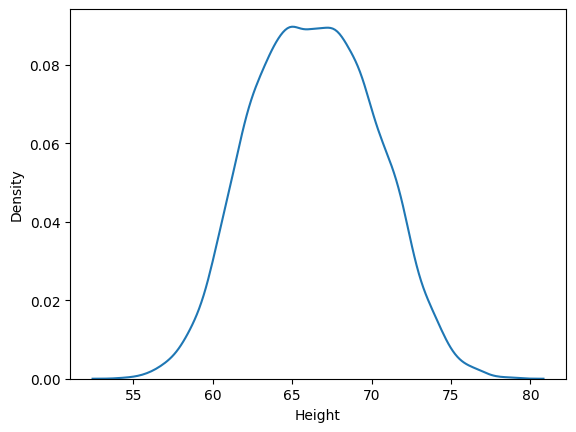

In [5]:
sns.kdeplot(df['Height'])

<Axes: ylabel='Height'>

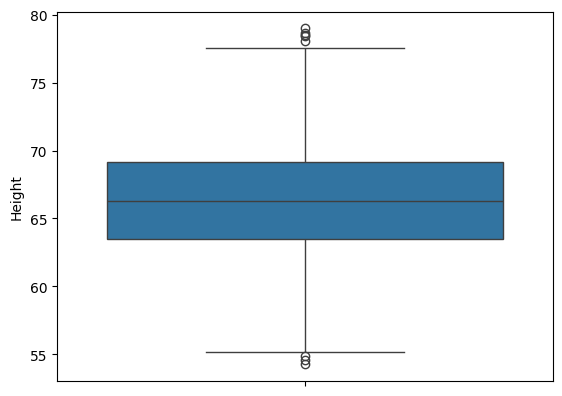

In [6]:
sns.boxplot(df['Height'])

In [7]:
upper_limit = df['Height'].quantile(0.99)  # take both side equal
upper_limit                      # for example upper 0.01 then take lower be same 0.01

np.float64(74.7857900583366)

In [9]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [11]:
df[(df['Height'] >= 74.78) | (df['Height'] <= 58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [12]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [13]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [16]:
new_df['Height'].describe()

,Height
count,9799.000000
mean,66.363507
std,3.644267
min,58.134496
25%,63.577147
50%,66.317899
75%,69.119859
max,74.767447


<Axes: xlabel='Height', ylabel='Density'>

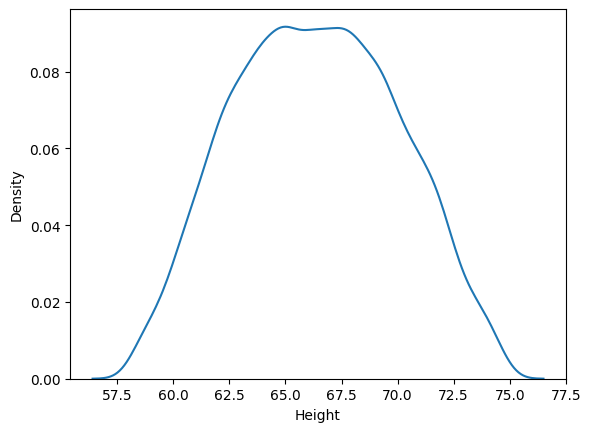

In [17]:
sns.kdeplot(new_df['Height'])

<Axes: ylabel='Height'>

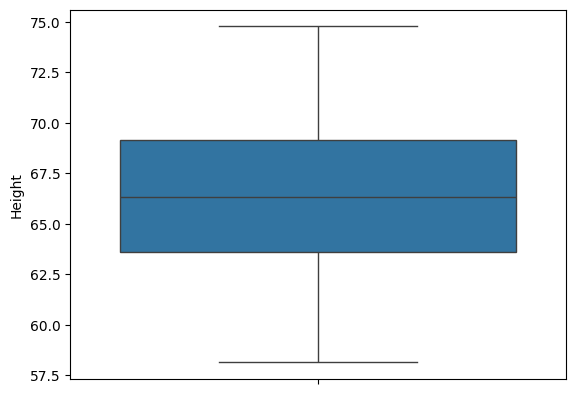

In [18]:
sns.boxplot(new_df['Height'])

# copping

In [21]:
df['Height'] = np.where(df['Height'] >= upper_limit, upper_limit,
         np.where(df['Height'] <= lower_limit, lower_limit, df['Height']))

In [23]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699


<Axes: ylabel='Height'>

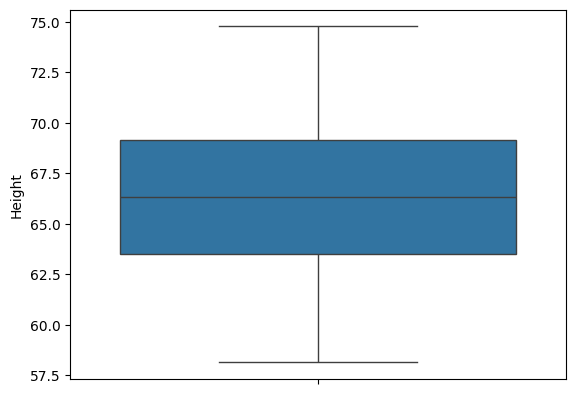

In [24]:
sns.boxplot(df['Height'])

<Axes: xlabel='Height', ylabel='Density'>

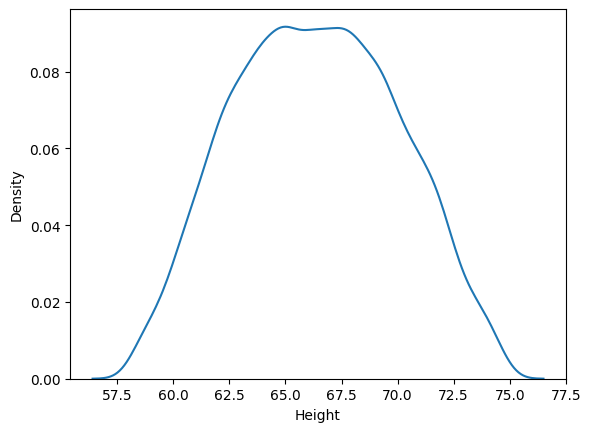

In [25]:
sns.kdeplot(new_df['Height'])